# Heart Disease Dataset - Exploratory Data Analysis (EDA)

## MLOps Assignment - Task 1: Data Acquisition & EDA [5 Marks]

This notebook performs comprehensive EDA on the Heart Disease UCI dataset.

## 1. Import Libraries

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

print('Libraries imported successfully!')

Libraries imported successfully!


## 2. Load Dataset

In [5]:
# Load the preprocessed dataset
data_path = Path('../data/processed/heart_disease_preprocessed.csv')

if data_path.exists():
    df = pd.read_csv(data_path)
    print(f'Dataset loaded successfully!')
    print(f'Shape: {df.shape}')
else:
    # Fallback to raw data
    raw_path = Path('../data/raw/heart_disease.csv')
    if raw_path.exists():
        df = pd.read_csv(raw_path)
        print(f'Raw dataset loaded. Shape: {df.shape}')
    else:
        print('Please run download_data.py first!')

Dataset loaded successfully!
Shape: (303, 14)


## 3. Dataset Overview

In [6]:
# Basic info
print('='*60)
print('DATASET INFORMATION')
print('='*60)
print(f'\nNumber of samples: {len(df)}')
print(f'Number of features: {len(df.columns) - 1}')
print(f'Target column: target')

print('\n' + '='*60)
print('COLUMN INFORMATION')
print('='*60)
df.info()

DATASET INFORMATION

Number of samples: 303
Number of features: 13
Target column: target

COLUMN INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    float64
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(4), int64(10)
memory usage: 33.3 KB


In [7]:
# First few rows
print('First 5 rows:')
df.head()

First 5 rows:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,1,145.0,233.0,1,2,150.0,0,2.3,3,0,6,0
1,67,1,4,160.0,286.0,0,2,108.0,1,1.5,2,3,3,1
2,67,1,4,120.0,229.0,0,2,129.0,1,2.6,2,2,7,1
3,37,1,3,130.0,250.0,0,0,187.0,0,3.5,3,0,3,0
4,41,0,2,130.0,204.0,0,2,172.0,0,1.4,1,0,3,0


In [8]:
# Statistical summary
print('Statistical Summary:')
df.describe()

Statistical Summary:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.663366,4.722772,0.458746
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.934375,1.938383,0.499120
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,1.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,1.000000


## 4. Missing Values Analysis

In [9]:
# Check missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Values': missing,
    'Percentage': missing_pct
})

print('Missing Values Summary:')
print(missing_df[missing_df['Missing Values'] > 0])

if missing.sum() == 0:
    print('\n✅ No missing values in the dataset!')

Missing Values Summary:
Empty DataFrame
Columns: [Missing Values, Percentage]
Index: []

✅ No missing values in the dataset!


## 5. Target Variable Analysis (Class Balance)

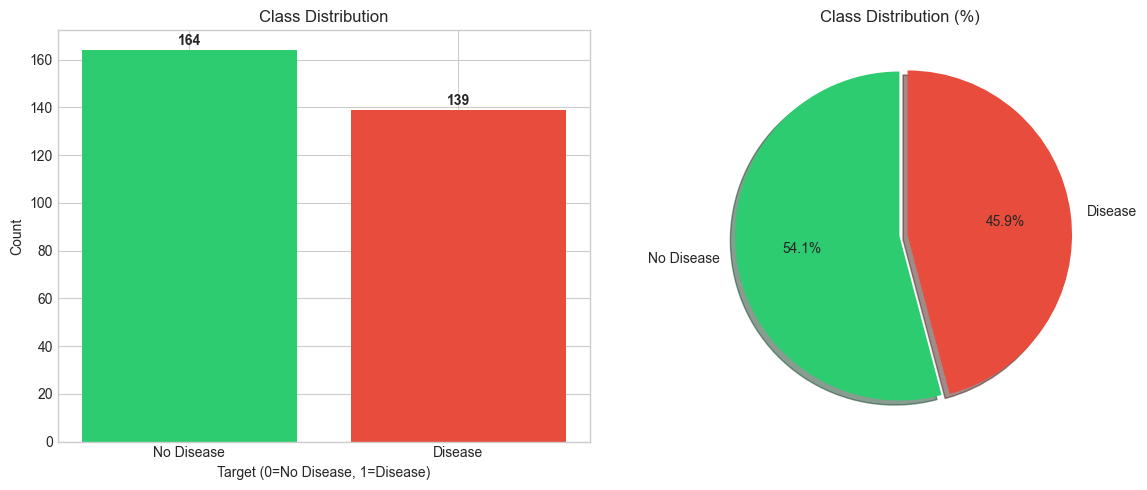


Class distribution:
  No Disease (0): 164 (54.1%)
  Disease (1): 139 (45.9%)


In [10]:
# Class distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Count plot
target_counts = df['target'].value_counts()
colors = ['#2ecc71', '#e74c3c']

axes[0].bar(target_counts.index, target_counts.values, color=colors)
axes[0].set_xlabel('Target (0=No Disease, 1=Disease)')
axes[0].set_ylabel('Count')
axes[0].set_title('Class Distribution')
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['No Disease', 'Disease'])

# Add count labels
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 2, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(target_counts.values, labels=['No Disease', 'Disease'], 
            autopct='%1.1f%%', colors=colors, explode=[0, 0.05],
            shadow=True, startangle=90)
axes[1].set_title('Class Distribution (%)')

plt.tight_layout()
plt.savefig('../screenshots/class_distribution.png', dpi=150)
plt.show()

print(f'\nClass distribution:')
print(f'  No Disease (0): {target_counts[0]} ({target_counts[0]/len(df)*100:.1f}%)')
print(f'  Disease (1): {target_counts[1]} ({target_counts[1]/len(df)*100:.1f}%)')

## 6. Feature Distributions (Histograms)

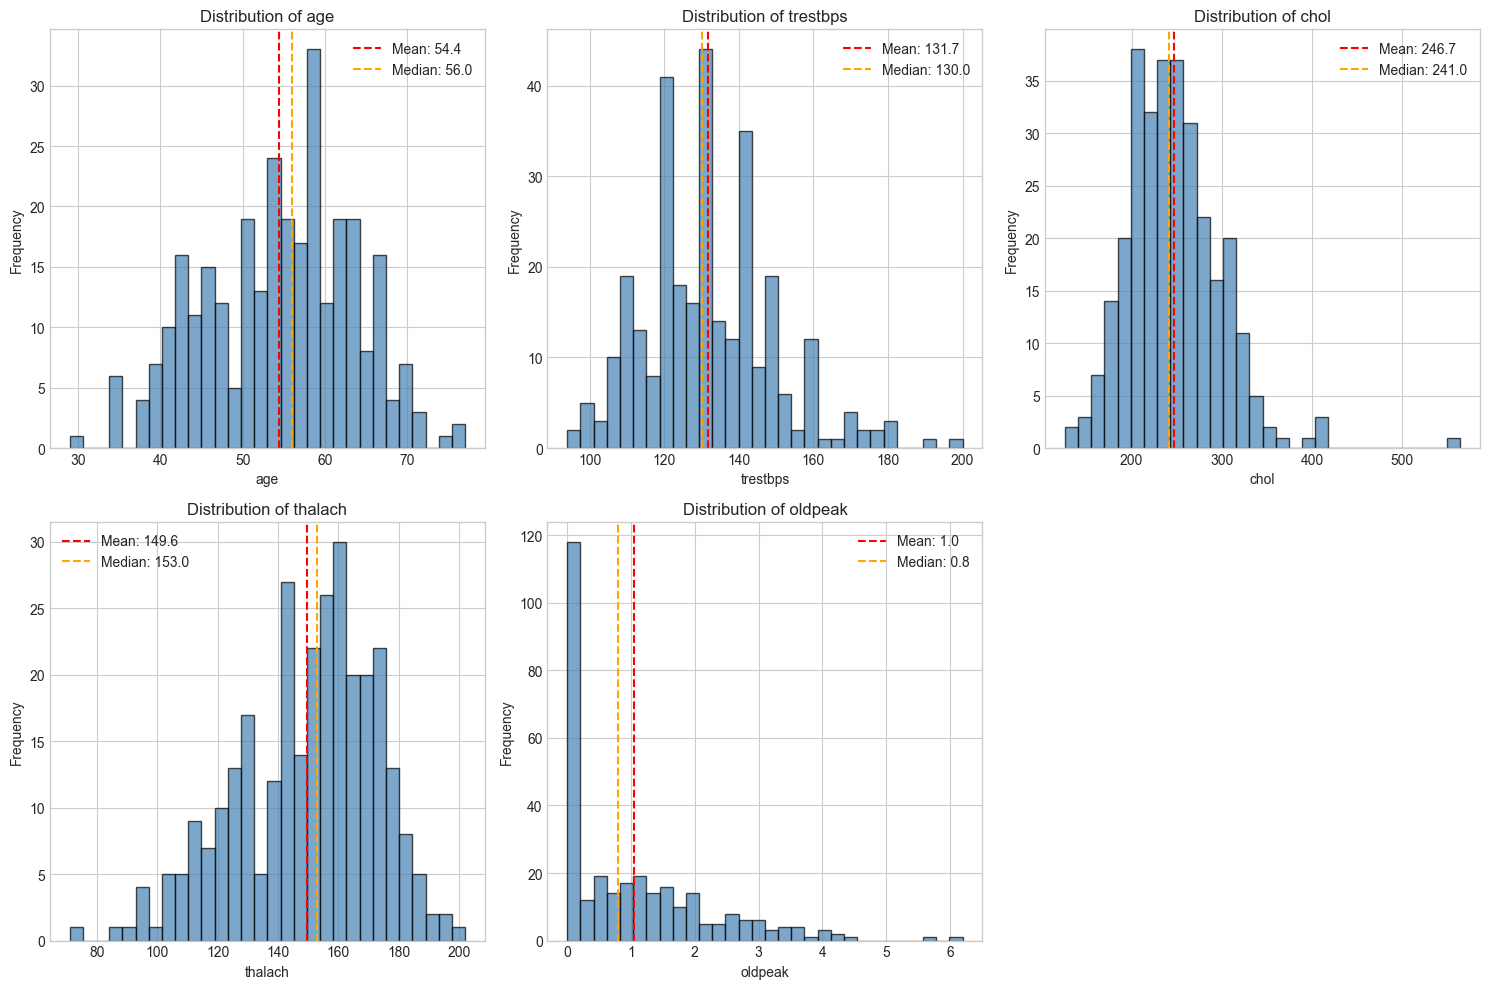

In [11]:
# Numeric feature distributions
numeric_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, feature in enumerate(numeric_features):
    # Histogram
    axes[i].hist(df[feature], bins=30, edgecolor='black', alpha=0.7, color='steelblue')
    axes[i].axvline(df[feature].mean(), color='red', linestyle='--', label=f'Mean: {df[feature].mean():.1f}')
    axes[i].axvline(df[feature].median(), color='orange', linestyle='--', label=f'Median: {df[feature].median():.1f}')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Frequency')
    axes[i].set_title(f'Distribution of {feature}')
    axes[i].legend()

# Remove empty subplot
axes[-1].axis('off')

plt.tight_layout()
plt.savefig('../screenshots/feature_distributions.png', dpi=150)
plt.show()

## 7. Correlation Analysis (Heatmap)

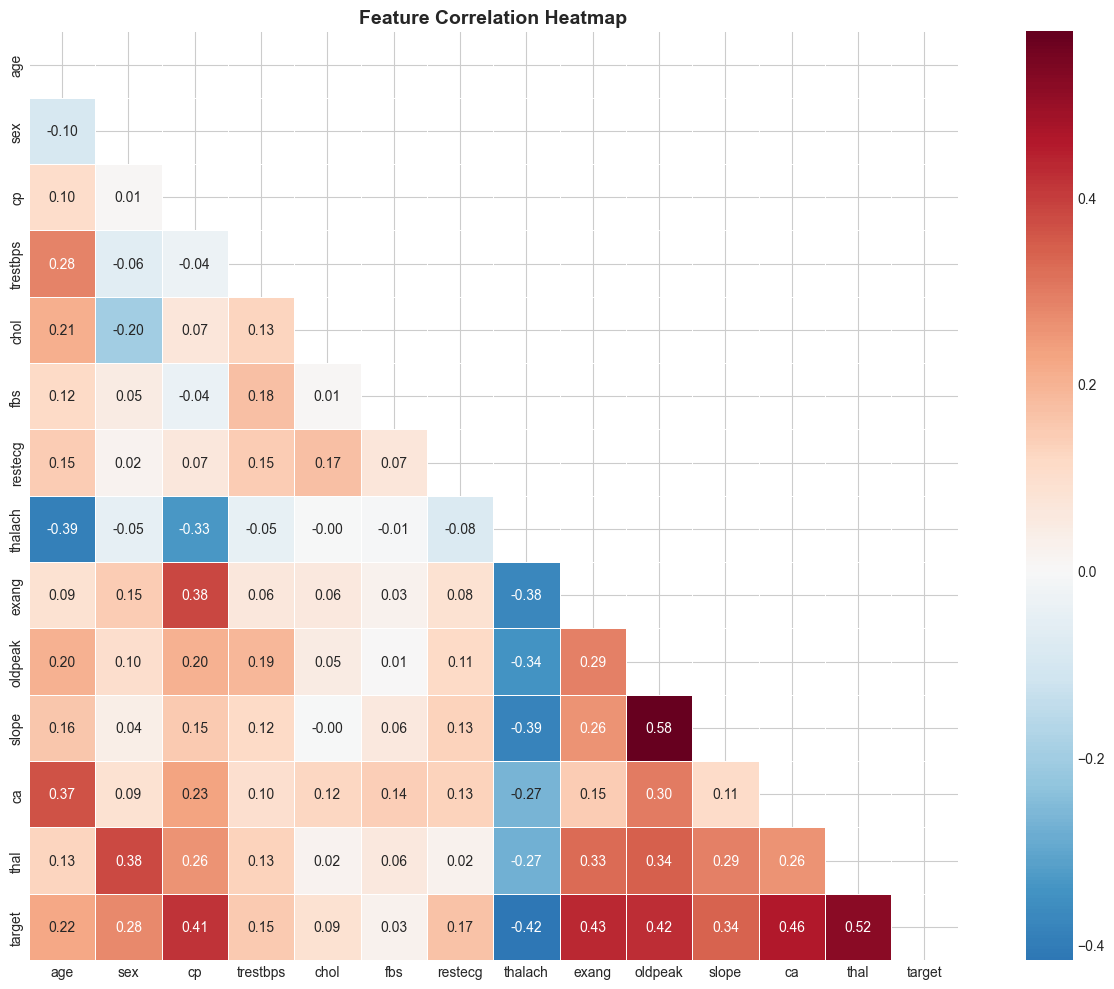


Top correlations with target variable:
thal        0.522057
ca          0.460033
exang       0.431894
oldpeak     0.424510
thalach    -0.417167
cp          0.414446
slope       0.339213
sex         0.276816
age         0.223120
restecg     0.169202
trestbps    0.150825
chol        0.085164
fbs         0.025264
Name: target, dtype: float64


In [12]:
# Correlation heatmap
plt.figure(figsize=(14, 10))

correlation_matrix = df.corr()

mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

sns.heatmap(correlation_matrix, 
            mask=mask,
            annot=True, 
            fmt='.2f', 
            cmap='RdBu_r',
            center=0,
            square=True,
            linewidths=0.5)

plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../screenshots/correlation_heatmap.png', dpi=150)
plt.show()

# Top correlations with target
print('\nTop correlations with target variable:')
target_corr = correlation_matrix['target'].drop('target').sort_values(key=abs, ascending=False)
print(target_corr)

## 8. Feature vs Target Analysis

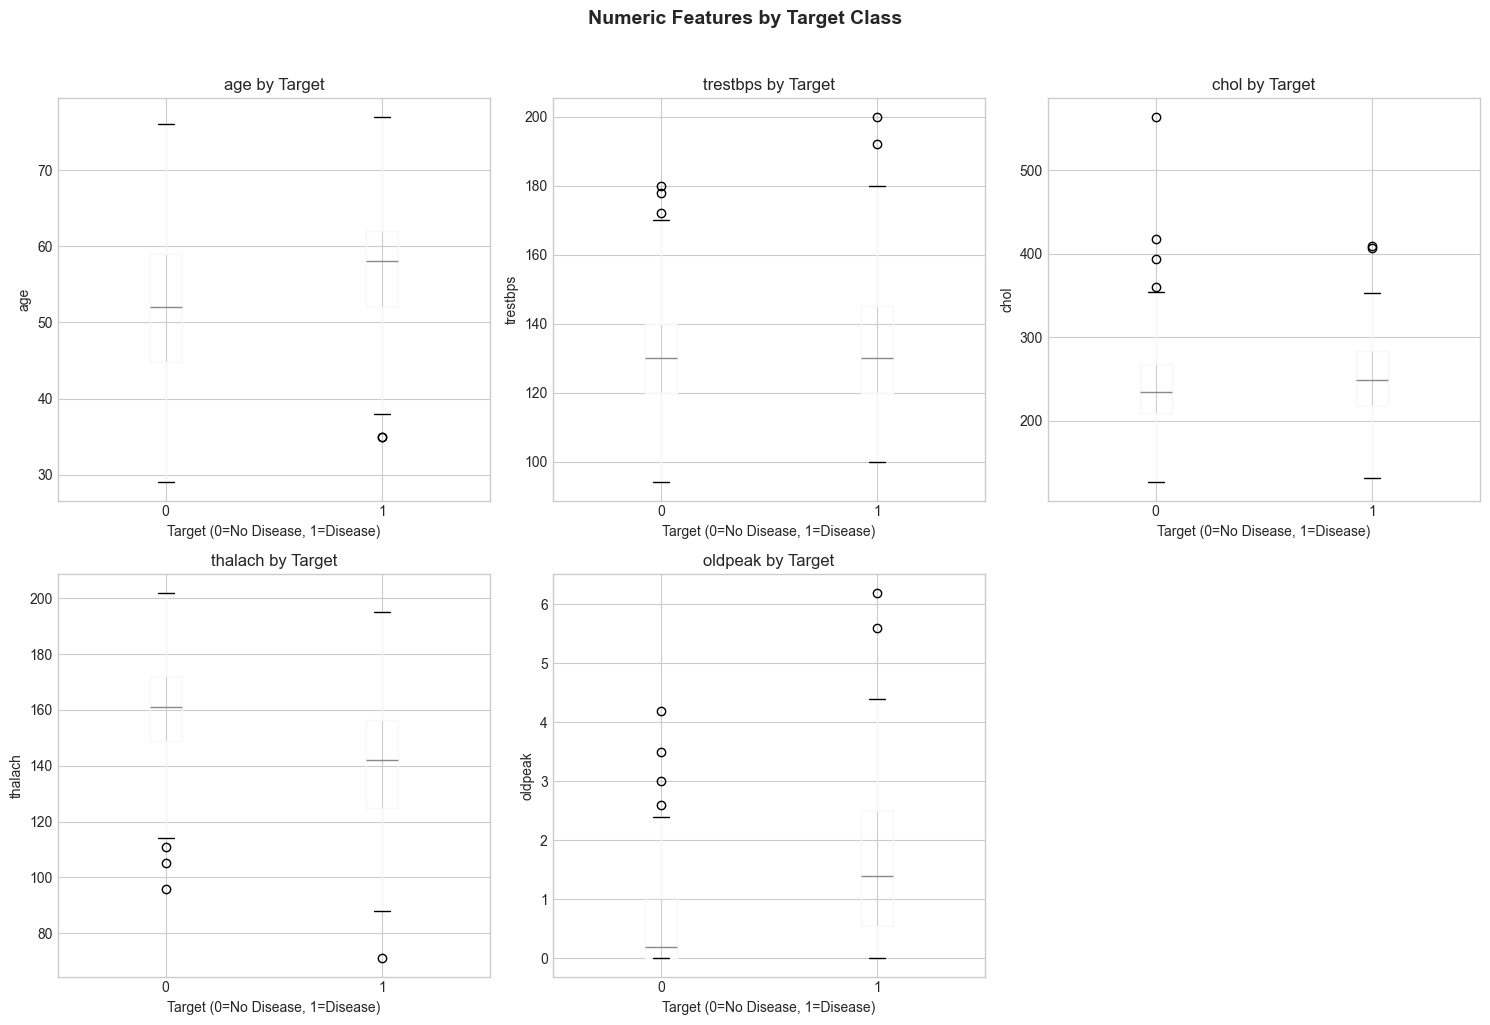

In [13]:
# Box plots for numeric features by target
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, feature in enumerate(numeric_features):
    df.boxplot(column=feature, by='target', ax=axes[i])
    axes[i].set_xlabel('Target (0=No Disease, 1=Disease)')
    axes[i].set_ylabel(feature)
    axes[i].set_title(f'{feature} by Target')

axes[-1].axis('off')
plt.suptitle('Numeric Features by Target Class', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../screenshots/features_by_target.png', dpi=150)
plt.show()

## 9. Categorical Features Analysis

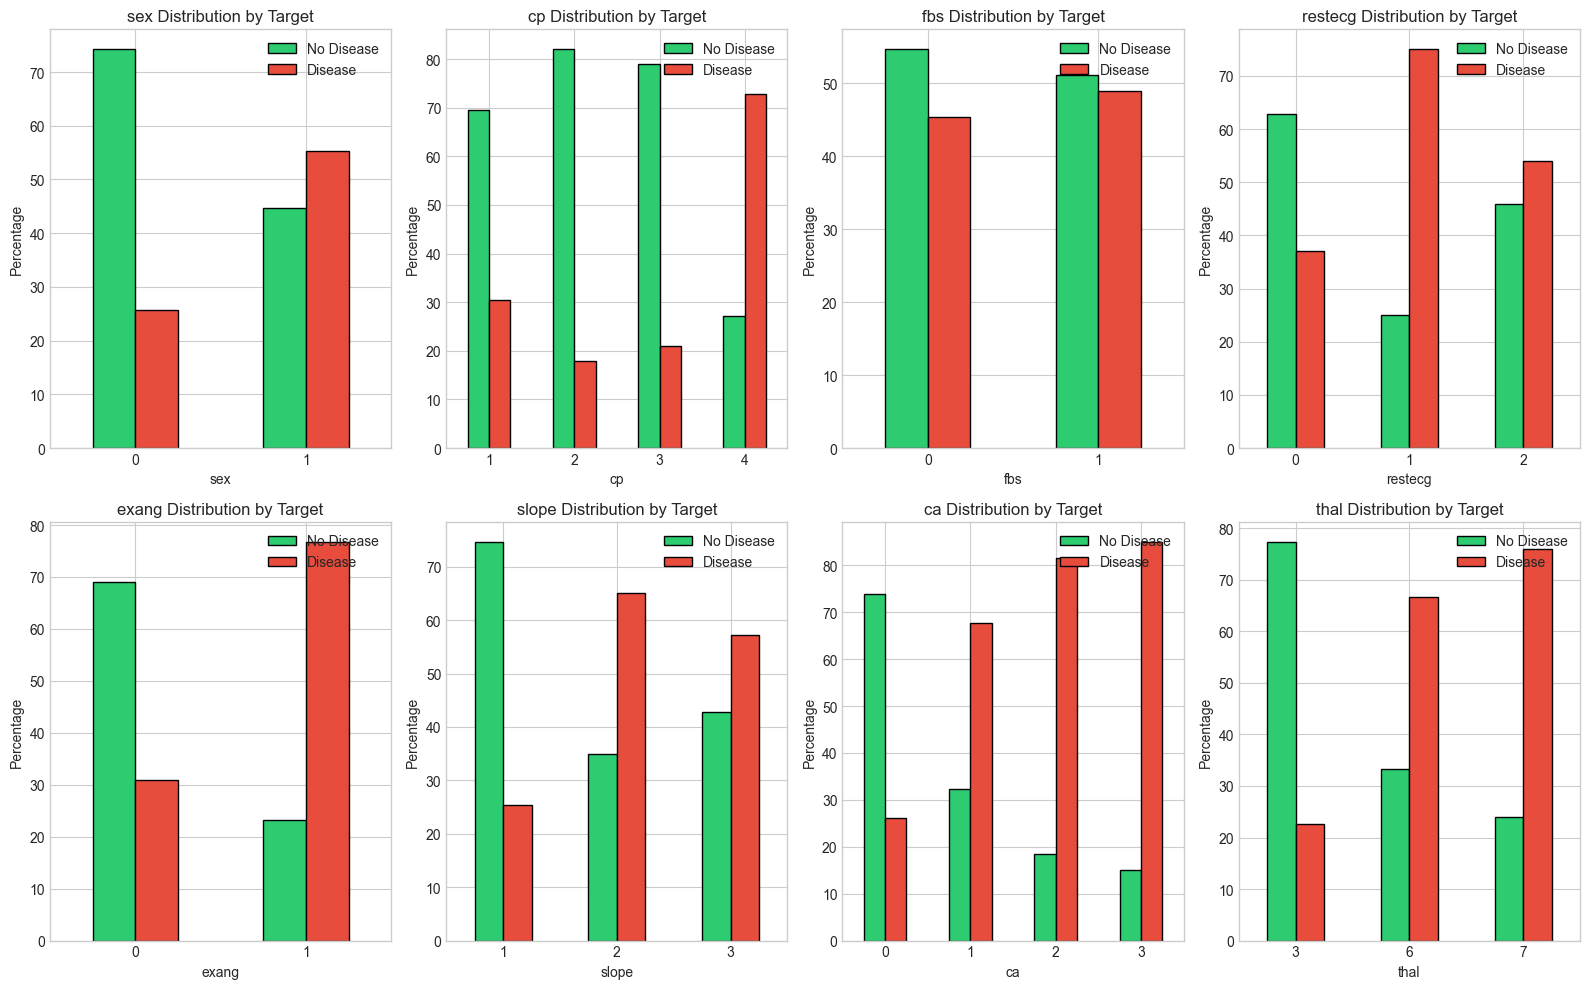

In [14]:
# Categorical features
categorical_features = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

fig, axes = plt.subplots(2, 4, figsize=(16, 10))
axes = axes.flatten()

for i, feature in enumerate(categorical_features):
    # Count by target
    ct = pd.crosstab(df[feature], df['target'])
    ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100
    
    ct_pct.plot(kind='bar', ax=axes[i], color=['#2ecc71', '#e74c3c'], edgecolor='black')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Percentage')
    axes[i].set_title(f'{feature} Distribution by Target')
    axes[i].legend(['No Disease', 'Disease'], loc='upper right')
    axes[i].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('../screenshots/categorical_features.png', dpi=150)
plt.show()

## 10. Key Insights Summary

In [15]:
print('='*60)
print('EDA KEY INSIGHTS')
print('='*60)

print(f'''
1. DATASET SIZE:
   - {len(df)} patients with {len(df.columns)-1} features
   - Target: Binary classification (Heart Disease: Yes/No)

2. CLASS BALANCE:
   - No Disease: {target_counts[0]} ({target_counts[0]/len(df)*100:.1f}%)
   - Disease: {target_counts[1]} ({target_counts[1]/len(df)*100:.1f}%)
   - Relatively balanced dataset

3. TOP CORRELATED FEATURES WITH TARGET:
   - {target_corr.index[0]}: {target_corr.iloc[0]:.3f}
   - {target_corr.index[1]}: {target_corr.iloc[1]:.3f}
   - {target_corr.index[2]}: {target_corr.iloc[2]:.3f}

4. DATA QUALITY:
   - Missing values: {df.isnull().sum().sum()}
   - Duplicates: {df.duplicated().sum()}

5. FEATURE OBSERVATIONS:
   - Age range: {df['age'].min():.0f} - {df['age'].max():.0f} years
   - Higher max heart rate (thalach) associated with no disease
   - Exercise-induced angina (exang) more common in disease cases
''')

print('='*60)
print('EDA Complete! Screenshots saved to screenshots/ folder')
print('='*60)

EDA KEY INSIGHTS

1. DATASET SIZE:
   - 303 patients with 13 features
   - Target: Binary classification (Heart Disease: Yes/No)

2. CLASS BALANCE:
   - No Disease: 164 (54.1%)
   - Disease: 139 (45.9%)
   - Relatively balanced dataset

3. TOP CORRELATED FEATURES WITH TARGET:
   - thal: 0.522
   - ca: 0.460
   - exang: 0.432

4. DATA QUALITY:
   - Missing values: 0
   - Duplicates: 0

5. FEATURE OBSERVATIONS:
   - Age range: 29 - 77 years
   - Higher max heart rate (thalach) associated with no disease
   - Exercise-induced angina (exang) more common in disease cases

EDA Complete! Screenshots saved to screenshots/ folder
